# 11 · 토스 낚시 행동 — 과거 로그의 계측 가능성 감사

**한 줄 답:** 현재 로그는 낚싯대 던지기 시각은 알려주지만, 기기 고정 배정과 적격성·실제 노출을 재구성하지 못한다.

이 노트북은 당시 제안했던 라이브 안내 안을 과거 GA4로 어디까지 검토할 수 있는지 감사한 기록이다. **라이브 안은 사용자 뜻과 달라 철회했고 설계서·코드도 삭제했다.** 여기의 과거 행동 수치와 한계만 오프라인 코호트 정의에 참고한다. 배너 효과나 예측모델을 검정한 것은 아니다.

**조회 전 G1 통과 기준:** 토스 기기 식별 키와 튜토리얼 종료·낚시 행동 시각을 연결하고, 유급 테스터 제외·기존 예측 배너 겹침을 검증하며, 배정 시점의 과거 낚시 여부·호숫가 위치·낚싯대 사용 가능 상태를 기록할 방법이 확인돼야 한다. 하나라도 미확인이면 미통과.

## 1. 범위와 제외

- BigQuery GA4의 완전 일별 export 2026-09-04~12(KST). Intraday는 제외한다.
- 이벤트 파라미터 `platform='toss'`만 토스로 판정한다. `(direct)` 유입 소스는 쓰지 않는다.
- 기록된 `beta_A/B` 행은 제외한다. 미표식 유급 테스터는 남을 수 있다.
- `user_pseudo_id`는 기기/브라우저 관측 키이지 사람이 아니다. 원시 ID는 결과로 내보내지 않는다.
- 튜토리얼 종료·건너뛰기 기록이 없다는 이유만으로 미완료라고 단정하지 않는다. `tutorial_skip`은 환영 화면과 코치 중단에 공용이다.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
from IPython.display import Markdown, display
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT/'ml'))
from calm_ml import bq, report as R
R.setup()
EVENT_SQL = ROOT/'ml/sql/g1_toss_fishing_event_readiness.sql'
FLOW_SQL = ROOT/'ml/sql/g1_toss_fishing_candidate_flow.sql'
SEM_SQL = ROOT/'ml/sql/g1_toss_fishing_tutorial_semantics.sql'
OUT = ROOT/'ml/reports/g1_toss_fishing_readiness_2026-09-14'
OUT.mkdir(parents=True, exist_ok=True)
print('SQL 원본:', EVENT_SQL, FLOW_SQL, SEM_SQL)


SQL 원본: /Users/uicheol_hwang/calm_forest/ml/sql/g1_toss_fishing_event_readiness.sql /Users/uicheol_hwang/calm_forest/ml/sql/g1_toss_fishing_candidate_flow.sql /Users/uicheol_hwang/calm_forest/ml/sql/g1_toss_fishing_tutorial_semantics.sql


## 2. SQL 원문과 원시 결과

첫 SQL은 이벤트별 기기·세션·클라이언트 ID 파라미터를 센다. 둘째 SQL은 같은 토스 기기에서 과거 로그로 복원되는 낚시 흐름을 센다. 아래 표가 해석 이전의 원시 집계다.

In [2]:
fence = chr(96)*3
display(Markdown(fence + 'sql\n' + EVENT_SQL.read_text(encoding='utf-8') + '\n' + fence))
display(Markdown(fence + 'sql\n' + FLOW_SQL.read_text(encoding='utf-8') + '\n' + fence))
display(Markdown(fence + 'sql\n' + SEM_SQL.read_text(encoding='utf-8') + '\n' + fence))
events = bq.read_sql_file(str(EVENT_SQL))
flow = bq.read_sql_file(str(FLOW_SQL))
semantics = bq.read_sql_file(str(SEM_SQL))
events.to_csv(OUT/'event_readiness.csv', index=False)
flow.to_csv(OUT/'candidate_flow.csv', index=False)
semantics.to_csv(OUT/'tutorial_semantics.csv', index=False)
display(events)
display(flow)
display(semantics)


```sql
-- G1: GA4가 토스 낚시 실험의 기기·튜토리얼·행동 시각을 연결할 수 있는지 감사.
-- 완전 일별 export 2026-09-04~12(KST)만 사용; intraday 제외.
-- event_params.platform='toss'만 토스로 간주하고, 표시된 beta_A/B 행은 제외.
-- 미표식 유급 테스터가 남을 수 있으며, ID 값은 집계 밖으로 내보내지 않는다.
WITH events AS (
  SELECT
    event_name, event_timestamp, user_pseudo_id,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='platform' LIMIT 1) AS platform,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='client_id' LIMIT 1) AS client_id_param,
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep
      WHERE ep.key='ga_session_id' LIMIT 1) AS ga_session_id,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key='ab_variant' LIMIT 1) AS ab_variant,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='arm' LIMIT 1) AS arm,
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep
      WHERE ep.key='shown' LIMIT 1) AS shown_int,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='shown' LIMIT 1) AS shown_string
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
), toss AS (
  SELECT * FROM events
  WHERE platform='toss'
    AND NOT REGEXP_CONTAINS(COALESCE(ab_variant,''), r'^beta_[AB]$')
)
SELECT
  event_name,
  COUNT(*) AS event_rows,
  COUNT(DISTINCT user_pseudo_id) AS devices,
  COUNTIF(user_pseudo_id IS NULL) AS missing_pseudo_rows,
  COUNTIF(ga_session_id IS NOT NULL) AS ga_session_rows,
  COUNTIF(client_id_param IS NOT NULL) AS client_id_rows,
  COUNTIF(arm IS NOT NULL) AS arm_rows,
  COUNTIF(shown_int IS NOT NULL OR shown_string IS NOT NULL) AS shown_param_rows
FROM toss
WHERE event_name IN (
  'tutorial_complete','tutorial_skip','fishing_cast','fishing_catch',
  'churn_score','zone_enter','recommendation_impression','experiment_assign'
)
GROUP BY event_name
ORDER BY event_rows DESC, event_name;

```

```sql
-- G1: 과거 로그로 복원 가능한 퍼널의 최대 범위를 확인한다.
-- 이 표는 적격자나 실험 결과가 아니다. 호숫가 위치·도구 상태·진짜 첫 세션은 미계측.
-- 완전 GA4 일별 export 2026-09-04~12(KST), platform=toss, 표시 beta_A/B 제외.
WITH events AS (
  SELECT
    user_pseudo_id, event_name, event_timestamp,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='platform' LIMIT 1) AS platform,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key='ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
), toss AS (
  SELECT * FROM events
  WHERE platform='toss' AND user_pseudo_id IS NOT NULL
    AND NOT REGEXP_CONTAINS(COALESCE(ab_variant,''), r'^beta_[AB]$')
), per_device AS (
  SELECT
    user_pseudo_id,
    MIN(event_timestamp) AS first_toss_ts,
    MIN(IF(event_name IN ('tutorial_complete','tutorial_skip'), event_timestamp, NULL)) AS tutorial_end_ts,
    MIN(IF(event_name='fishing_cast', event_timestamp, NULL)) AS first_cast_ts,
    MIN(IF(event_name='fishing_catch', event_timestamp, NULL)) AS first_catch_ts,
    COUNTIF(event_name='churn_score') AS score_rows
  FROM toss GROUP BY user_pseudo_id
)
SELECT
  COUNT(*) AS toss_devices,
  COUNTIF(tutorial_end_ts IS NOT NULL) AS tutorial_end_devices,
  COUNTIF(first_cast_ts IS NOT NULL) AS cast_devices,
  COUNTIF(first_catch_ts IS NOT NULL) AS catch_devices,
  COUNTIF(tutorial_end_ts IS NOT NULL AND first_cast_ts IS NOT NULL
    AND first_cast_ts >= tutorial_end_ts) AS cast_after_tutorial_devices,
  COUNTIF(tutorial_end_ts IS NOT NULL AND first_cast_ts BETWEEN tutorial_end_ts
    AND tutorial_end_ts + 10*60*1000000) AS cast_within_10m_of_tutorial_devices,
  COUNTIF(score_rows > 0) AS scored_devices
FROM per_device;

```

```sql
-- G1 정정 확인: tutorial_skip은 환영 모달 건너뛰기와 코치 중단에 공용이다.
-- 완전 GA4 일별 export 2026-09-04~12(KST), toss 이벤트, 표시 beta_A/B 제외.
WITH events AS (
  SELECT
    event_name, user_pseudo_id,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key='platform' LIMIT 1) AS platform,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key='ab_variant' LIMIT 1) AS ab_variant,
    (SELECT COALESCE(ep.value.string_value, CAST(ep.value.int_value AS STRING))
      FROM UNNEST(event_params) ep WHERE ep.key='at' LIMIT 1) AS at_value
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
)
SELECT event_name, COALESCE(at_value,'(없음)') AS at_value,
  COUNT(*) AS event_rows, COUNT(DISTINCT user_pseudo_id) AS devices
FROM events
WHERE platform='toss'
  AND NOT REGEXP_CONTAINS(COALESCE(ab_variant,''), r'^beta_[AB]$')
  AND event_name IN ('tutorial_complete','tutorial_skip')
GROUP BY event_name, at_value
ORDER BY event_name, event_rows DESC;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_name,event_rows,devices,missing_pseudo_rows,ga_session_rows,client_id_rows,arm_rows,shown_param_rows
0,zone_enter,257,10,0,257,0,0,0
1,churn_score,217,15,0,217,0,217,171
2,fishing_cast,209,6,0,209,0,0,0
3,fishing_catch,190,6,0,190,0,0,0
4,tutorial_skip,23,19,0,23,0,0,0
5,tutorial_complete,2,2,0,2,0,0,0


,toss_devices,tutorial_end_devices,cast_devices,catch_devices,cast_after_tutorial_devices,cast_within_10m_of_tutorial_devices,scored_devices
0,49,20,6,6,4,2,15


,event_name,at_value,event_rows,devices
0,tutorial_complete,(없음),2,2
1,tutorial_skip,welcome,16,15
2,tutorial_skip,1,3,3
3,tutorial_skip,-1,2,1
4,tutorial_skip,5,1,1
5,tutorial_skip,8,1,1


## 3. 기록으로 확인되는 기기 수

아래는 **계측 가용 범위**이지 실험 퍼널이 아니다. 10분 수치는 종료·건너뛰기 이벤트와 첫 던지기 양쪽의 기록이 있는 기기에만 계산할 수 있다.

,기록 단계,기기 수
0,토스 이벤트 관측,49
1,온보딩 종료·건너뛰기 기록,20
2,낚싯대 던지기 기록,6
3,해당 기록 뒤 10분 내 첫 던지기,2


g1_toss_fishing_observability.png  1203x631px


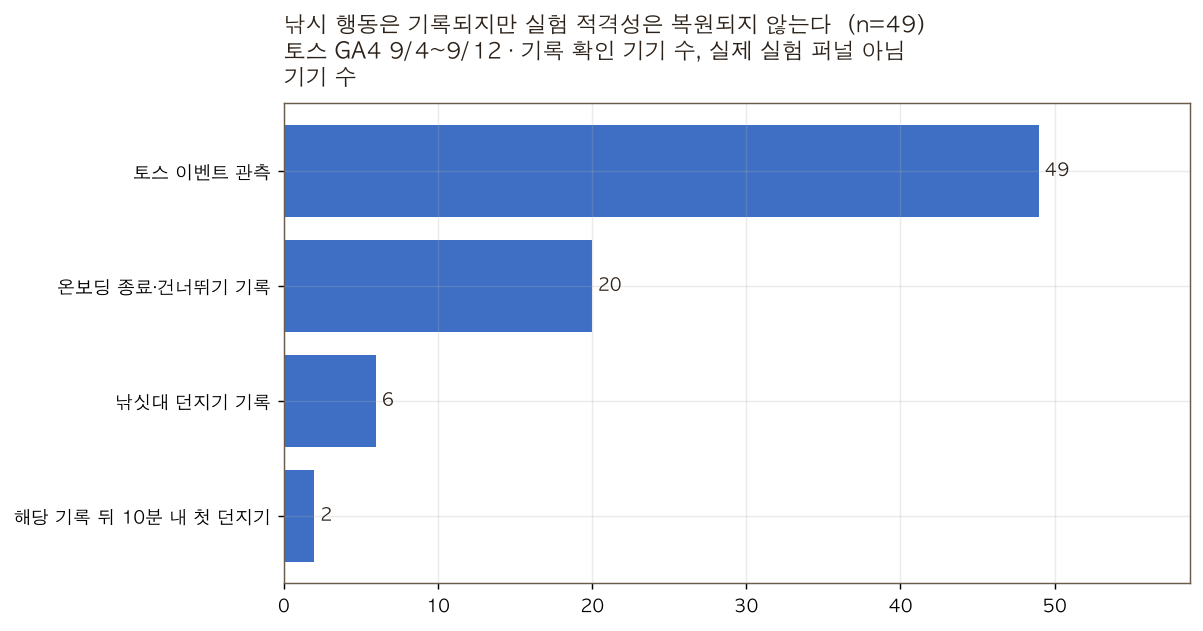

In [3]:
f = flow.iloc[0]
coverage = pd.DataFrame({
    '기록 단계': ['토스 이벤트 관측', '온보딩 종료·건너뛰기 기록', '낚싯대 던지기 기록', '해당 기록 뒤 10분 내 첫 던지기'],
    '기기 수': [int(f.toss_devices), int(f.tutorial_end_devices), int(f.cast_devices),
              int(f.cast_within_10m_of_tutorial_devices)],
})
coverage.to_csv(OUT/'observability.csv', index=False)
display(coverage)
fig, ax = R.new('낚시 행동은 기록되지만 실험 적격성은 복원되지 않는다', int(f.toss_devices),
                sub='토스 GA4 9/4~9/12 · 기록 확인 기기 수, 실제 실험 퍼널 아님',
                ylab='기기 수', figsize=(9, 4.8))
bars = ax.barh(coverage['기록 단계'], coverage['기기 수'], color=R.PALETTE[1])
ax.invert_yaxis(); ax.bar_label(bars, padding=3)
ax.set_xlim(0, int(f.toss_devices)*1.2)
chart = R.save(fig, ax, 'g1_toss_fishing_observability', zero_base=False)
print(R.check(chart)); display(R.show(chart))


## 4. 그래서 크기가 얼마나 되나

- 토스 관측 **49기기** 중 튜토리얼 종료·건너뛰기 이벤트는 **20기기**에 있다. 이 중 `welcome` 건너뛰기는 16건/15기기다.
- `fishing_cast` **209건**은 **6기기**가 남겼다. 이벤트 건수를 독립 이용자 수로 보면 크게 부풀린다.
- 첫 던지기가 이 종료·건너뛰기 기록 뒤 10분 안에 관측된 기기는 **2기기**다. 안내를 배정한 적이 없으므로 실험 전환율이 아니다.
- `churn_score` **217건/15기기**에는 arm은 붙지만 GA4 이벤트 파라미터 `client_id`는 **0건**이다.

## 5. 코드로 확인한 준비도

- VM `/predict`는 점수·개입 여부를 계산한다. 배너 종류·표시·낚시 행동은 브라우저에서 결정된다. VM JSONL만으로 노출·행동을 알 수 없다.
- `js/analytics.js`의 GA4 공통 이벤트에는 `platform`과 `ts`가 붙지만 `client_id`는 붙지 않는다. 자체 세션 로그에는 `client_id`가 있다. 기기 고정 배정과 GA4 결과를 잇는 실험 ID 계약이 필요하다.
- `fishing_cast`는 실제 호숫가 거리 검사와 던지기 성공 뒤 `js/game.js`에서 기록된다. `fishing_catch`는 별개 결과다.
- 호숫가 거리·낚싯대 사용 가능·기존 던지기 이력은 배정 시점의 클라이언트 상태/이력이 필요하다. 과거 GA4만으로 전부 재구성할 수 없다.
- `tutorial_complete`는 코치 졸업, `tutorial_skip`은 환영 화면 건너뛰기·코치 중단·안내서에서 다시 연 화면 닫기에 공용이다. 인트로 `intro_complete/skip`와도 다르다. 종료·건너뛰기 기록 없는 29기기를 미완료로 해석하지 않는다.

## 정정 기록

첫 집계 직후 20기기를 ‘튜토리얼 종료’라고 불렀다. 코드 확인 뒤 `tutorial_skip.at`을 추가 조회하니 `welcome` 16건/15기기와 숫자 단계의 중단 7건이 섞여 있었다. 그래서 본문·차트의 라벨을 ‘종료·건너뛰기 기록’으로 고쳤다. 첫 관측 이벤트가 실제 첫 조작 가능 시점이라는 보장도 없다.

## 6. 이 숫자로 말할 수 없는 것

미표식 테스터, 관측 범위 이전의 낚시 이력, 타 플랫폼 선행 플레이, 미기록 호숫가 도착, 실제 음향 청취는 배제·복원할 수 없다. 기존 `9/49`는 낚시·바다 영역 도달이고 이번 `6/49`는 낚싯대 던지기이므로 같은 지표가 아니다. 10분 내 2기기를 새 배너의 예상 전환율로 쓰지 않는다.

## 7. G1 판정과 다음 확인

**당시 라이브 계측안은 미통과이며 현재 철회됐다.** 결과 이벤트 시각·GA4 기기 키는 있으나 배정 ID, 배정 시점 적격 상태, 실제 노출, 유급 테스터 확실한 제외가 없다. 이 한계는 오프라인 코호트/라벨 정의에도 그대로 반영해야 한다.

W&B 외부 업로드는 앞선 안전 검토의 보류 상태라 이 노트북과 집계는 로컬에만 남긴다.

## 8. 범위 정정 — 라이브 실험 철회

사용자가 말한 실험은 **주어진 로그로 추가 코호트를 정의하고, 그 정의를 테스트한 뒤, 오프라인 모델링으로 검증**하는 작업이다. 라이브 A/B, 배너 배포, Supabase 배정 장부는 원한 범위가 아니었다. 제가 라이브 실험으로 잘못 해석해 잠시 작성했던 코드·SQL·전용 테스트·설계 문서는 삭제했다. 운영 DB와 게임 배포는 건드리지 않았고 실제 배정·노출은 0건이다.

이 노트북 1~7절의 과거 GA4 집계는 남겨둔다. 특히 토스 관측 49기기 중 `fishing_cast`를 남긴 기기 6대라는 작은 양성 수와 튜토리얼 이벤트의 혼합 의미는 오프라인 코호트·라벨 설계에 중요한 제약이다. **안내 효과를 과거 로그로 검정할 수는 없다.** 다음 작업은 별도 게이트에서 오프라인 코호트 정의와 재현성·누수·표본 수를 먼저 테스트하는 것이다. 모델 학습은 그 기준을 통과한 뒤에만 진행한다.